# The Quartic Anharmonic Oscillator Propagator via Spectral Decomposition

This notebook computes the real-time quantum propagator
$$K(x_b, t \mid x_a, 0) = \langle x_b \mid e^{-iHt/\hbar} \mid x_a \rangle$$
for the one-dimensional quartic anharmonic oscillator with Hamiltonian
$$H = \frac{p^2}{2m} + \tfrac{1}{2} m \omega^2 x^2 + \tfrac{1}{4} \lambda x^4.$$

We work in units $m = \hbar = 1$ with $\omega = 2$ throughout, matching `QHO_Anharmonic_ML_LoopWithNN_StartFinish_General.ipynb`. The coupling $\lambda \geq 0$ is the only free parameter.

**Method.** The spectral decomposition
$$K(x_b, t \mid x_a, 0) = \sum_n \psi_n(x_a)\, \psi_n(x_b)\, e^{-i E_n t / \hbar}$$
is exact. We compute the $E_n$ and $\psi_n$ by diagonalising $H$ in a truncated harmonic-oscillator basis of size $N$. The only error is from basis truncation, which is exponentially small in $N$.

**Outline.**
1. Build the Hamiltonian matrix.
2. Diagonalise; check convergence.
3. Reconstruct eigenfunctions on a spatial grid.
4. Assemble the propagator.
5. Sanity checks: composition, Euclidean diagonalisation, $\langle x^2 \rangle_\beta$, parity, harmonic limit.
6. Tables of $K$ for varying $\lambda$ at multiple endpoints.
7. Plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

np.set_printoptions(precision=10, suppress=False, linewidth=130)

# Match QHO_Anharmonic_ML_LoopWithNN_StartFinish_General.ipynb conventions.
MASS = 1.0
HBAR = 1.0
OMEGA = 2.0
T_REF = 1.0
BETA_DIAG = 2.0
BETA_X2 = 1.0

## 1. Hamiltonian Matrix

In the HO basis with general $\omega$, $x = (a + a^\dagger)/\sqrt{2\omega}$ is tridiagonal. We compute $x^4 = (x^2)^2$ by matrix multiplication, then
$$H_{mn} = \omega(n + \tfrac{1}{2})\,\delta_{mn} + \tfrac{\lambda}{4}\,(x^4)_{mn}.$$

In [2]:
def build_hamiltonian(N, lam):
    """Returns (H, x_matrix) in HO basis of size N using global MASS/HBAR/OMEGA."""
    n = np.arange(N)
    x_mat = np.zeros((N, N))
    s = np.sqrt(HBAR * n[1:] / (2 * MASS * OMEGA))
    x_mat[np.arange(N-1), np.arange(1, N)] = s
    x_mat[np.arange(1, N), np.arange(N-1)] = s
    x2 = x_mat @ x_mat
    x4 = x2 @ x2
    H = np.diag(HBAR * OMEGA * (n + 0.5)) + 0.25 * lam * x4
    return H, x_mat

# Check: lambda=0 gives HBAR*OMEGA*0.5, HBAR*OMEGA*1.5, ...
H0, _ = build_hamiltonian(50, 0.0)
print(f"lambda=0 eigenvalues (m={MASS}, hbar={HBAR}, omega={OMEGA}):", eigh(H0, eigvals_only=True)[:6])

lambda=0 eigenvalues (m=1.0, hbar=1.0, omega=2.0): [ 1.  3.  5.  7.  9. 11.]


## 2. Diagonalisation and Convergence

With $\omega=2$ and $\lambda=1$, $E_0$ is computed below.

**Convention warning:** papers use $\lambda x^4$, $\lambda x^4/4$, $g x^4$, etc. Always check.

In [3]:
for N in [20, 40, 80, 160, 320]:
    H, _ = build_hamiltonian(N, 1.0)
    print(f"N={N:4d}:  E_0 = {eigh(H, eigvals_only=True)[0]:.14f}")
print(f"(omega = {OMEGA})")

N=  20:  E_0 = 1.04269782640629
N=  40:  E_0 = 1.04269782640648
N=  80:  E_0 = 1.04269782640648
N= 160:  E_0 = 1.04269782640648
N= 320:  E_0 = 1.04269782640648
(omega = 2.0)


In [4]:
N_BASIS = 400

def diagonalise(lam, N=N_BASIS):
    H, x_mat = build_hamiltonian(N, lam)
    evals, evecs = eigh(H)
    return evals, evecs, x_mat

## 3. Eigenfunctions on a Grid

Stable three-term recurrence for normalised HO wavefunctions ($m=\hbar=1$, general $\omega$):
$$\phi_0 = (\omega/\pi)^{1/4} e^{-\omega x^2/2},\quad \phi_1 = \sqrt{2\omega}\,x\,\phi_0,\quad \phi_n = \sqrt{\tfrac{2\omega}{n}}\,x\,\phi_{n-1} - \sqrt{\tfrac{n-1}{n}}\,\phi_{n-2}.$$
True eigenfunctions: $\psi_n(x) = \sum_m C_{mn}\,\phi_m(x)$.

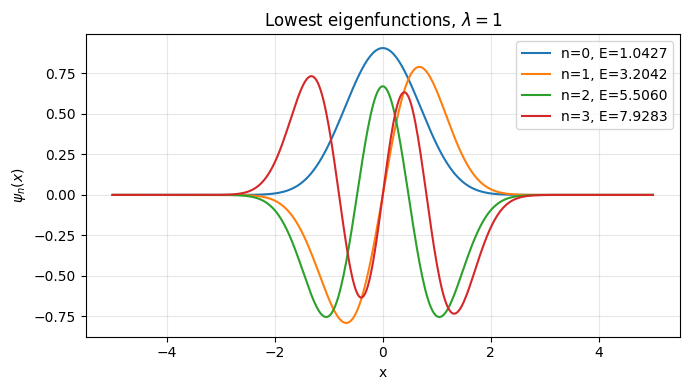

In [5]:
def ho_basis(N, x):
    Phi = np.zeros((N, len(x)))
    alpha = MASS * OMEGA / HBAR
    Phi[0] = (alpha / np.pi)**0.25 * np.exp(-0.5 * alpha * x**2)
    if N > 1:
        Phi[1] = np.sqrt(2.0 * alpha) * x * Phi[0]
    for n in range(2, N):
        Phi[n] = np.sqrt(2.0 * alpha / n) * x * Phi[n-1] - np.sqrt((n-1.0)/n) * Phi[n-2]
    return Phi

def eigenfunctions(C, x):
    return C.T @ ho_basis(C.shape[0], x)

# Plot
xg = np.linspace(-5, 5, 401)
ev, C, _ = diagonalise(1.0)
Psi = eigenfunctions(C, xg)
plt.figure(figsize=(7, 4))
for n in range(4):
    plt.plot(xg, Psi[n], label=f"n={n}, E={ev[n]:.4f}")
plt.xlabel("x"); plt.ylabel(r"$\psi_n(x)$")
plt.title(r"Lowest eigenfunctions, $\lambda=1$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. The Propagator

**Real time:** $K(x_b,t|x_a,0) = \sum_n \psi_n(x_a)\psi_n(x_b)e^{-iE_n t}.$

**Euclidean** ($t \to -i\beta$): $K_E(x_b,\beta|x_a,0) = \sum_n \psi_n(x_a)\psi_n(x_b)e^{-\beta E_n}.$ This is real, symmetric, positive.

In [6]:
def propagator(lam, xa, xb, t, N=N_BASIS):
    xa = np.atleast_1d(np.asarray(xa, float))
    xb = np.atleast_1d(np.asarray(xb, float))
    ev, C, _ = diagonalise(lam, N)
    Pa, Pb = eigenfunctions(C, xa), eigenfunctions(C, xb)
    K = np.einsum("ni,nj,n->ij", Pa, Pb, np.exp(-1j * ev * t / HBAR))
    return K.item() if K.size == 1 else K

def euclidean_prop(lam, xa, xb, beta, N=N_BASIS):
    xa = np.atleast_1d(np.asarray(xa, float))
    xb = np.atleast_1d(np.asarray(xb, float))
    ev, C, _ = diagonalise(lam, N)
    Pa, Pb = eigenfunctions(C, xa), eigenfunctions(C, xb)
    K = np.einsum("ni,nj,n->ij", Pa, Pb, np.exp(-beta * ev / HBAR))
    return K.item() if K.size == 1 else K

K_test = propagator(1.0, 0.5, 0.7, T_REF)
print(f"K(0.7, t={T_REF} | 0.5, 0) at lam=1: {K_test}")
print(f"|K| = {abs(K_test):.10f}")

K(0.7, t=1.0 | 0.5, 0) at lam=1: (-0.6192263338450533+0.2765717015858701j)
|K| = 0.6781837204


## 5. Sanity Checks

---

### 5.1 Composition (semigroup)

$$K(x, x''; t_1+t_2) = \int dx'\; K(x, x'; t_1)\,K(x', x''; t_2).$$
The integral is done numerically on a grid; residual error $\sim O(\Delta x^2)$.

In [7]:
def test_composition(lam, xa=0.4, xb=0.6, t1=0.4 * T_REF, t2=0.6 * T_REF,
                     x_max=8.0, n_grid=4001):
    xi = np.linspace(-x_max, x_max, n_grid)
    dx = xi[1] - xi[0]
    K1 = propagator(lam, xa, xi, t1)[0]
    K2 = propagator(lam, xi, xb, t2)[:, 0]
    K_comp = np.sum(K2 * K1) * dx
    K_dir  = propagator(lam, xa, xb, t1 + t2)
    print(f"  lam={lam:6.1f}:  |diff| = {abs(K_dir - K_comp):.3e}")

print(f"=== Test 1: Composition (t1+t2={T_REF}) ===")
for lam in [1.0, 10.0, 50.0, 100.0]:
    test_composition(lam)

=== Test 1: Composition (t1+t2=1.0) ===
  lam=   1.0:  |diff| = 8.543e-04
  lam=  10.0:  |diff| = 1.415e-03
  lam=  50.0:  |diff| = 8.573e-04
  lam= 100.0:  |diff| = 7.281e-04


### 5.2 Diagonalise $K_E$ as a matrix

Build $K_E(x_i, x_j; \beta)$ on a spatial grid. In the continuum,
$$\int dx'\, K_E(x, x'; \beta)\, \psi_n(x') = e^{-\beta E_n}\, \psi_n(x).$$
Discretised: the eigenvalues of $\mathbf{K}_E \cdot \Delta x$ should be $e^{-\beta E_n}$. We extract energies as $E_n = -\ln(\mathrm{eigenvalue})/\beta$ and compare to the $E_n$ from diagonalising $H$ directly.

In [8]:
def test_euclidean_diag(lam, beta=BETA_DIAG, x_max=6.0, n_grid=301, n_show=6):
    x = np.linspace(-x_max, x_max, n_grid)
    dx = x[1] - x[0]
    K_mat = euclidean_prop(lam, x, x, beta)
    eig_K = np.sort(np.linalg.eigvalsh(K_mat * dx))[::-1]
    evals_H, _, _ = diagonalise(lam)
    ref = np.exp(-beta * evals_H / HBAR)[:n_show]

    print(f"  lam={lam}, beta={beta}")
    print(f"  {'n':>3}  {'exp(-bE/hbar) [H]':>22}  {'eig [K_E]':>22}  {'|diff|':>10}")
    print(f"  " + "-"*60)
    for n in range(n_show):
        print(f"  {n:3d}  {ref[n]:>22.14e}  {eig_K[n]:>22.14e}  {abs(ref[n]-eig_K[n]):>10.2e}")

print(f"=== Test 2: Euclidean diagonalisation (beta={BETA_DIAG}) ===")
test_euclidean_diag(lam=1.0)
print()
test_euclidean_diag(lam=10.0)

=== Test 2: Euclidean diagonalisation (beta=2.0) ===
  lam=1.0, beta=2.0
    n       exp(-bE/hbar) [H]               eig [K_E]      |diff|
  ------------------------------------------------------------
    0    1.24257947432321e-01    1.24257947432321e-01    9.71e-17
    1    1.64772256559175e-03    1.64772256559180e-03    4.25e-17
    2    1.65032727780412e-05    1.65032727780410e-05    2.20e-19
    3    1.29895424852916e-07    1.29895424852284e-07    6.32e-19
    4    8.25854767426980e-10    8.25854767814621e-10    3.88e-19
    5    4.32929122773943e-12    4.32929091419957e-12    3.14e-19

  lam=10.0, beta=2.0
    n       exp(-bE/hbar) [H]               eig [K_E]      |diff|
  ------------------------------------------------------------
    0    7.66689961627555e-02    7.66689961627557e-02    1.25e-16
    1    2.15246650917601e-04    2.15246650917602e-04    9.76e-19
    2    1.82352259535942e-07    1.82352259536204e-07    2.62e-19
    3    6.80102497071888e-11    6.80102500283985e-11

### 5.3 Thermal $\langle x^2 \rangle_\beta$

$$\langle x^2 \rangle_\beta = \frac{\mathrm{Tr}(x^2 e^{-\beta H})}{\mathrm{Tr}(e^{-\beta H})} = \frac{\sum_n \langle n|x^2|n\rangle e^{-\beta E_n}}{\sum_n e^{-\beta E_n}}.$$

**Method A** (from $K_E$ diagonal on a grid):
$$\langle x^2 \rangle_\beta = \frac{\sum_i x_i^2\, K_E(x_i, x_i; \beta)\, \Delta x}{\sum_i K_E(x_i, x_i; \beta)\, \Delta x}.$$

**Method B** (from spectrum): rotate $x^2$ to energy eigenbasis, $\langle n|x^2|n\rangle = (C^T x^2 C)_{nn}$, then weight by Boltzmann factors.

Agreement = confidence that both the Euclidean propagator and the spectral quantities are correct.

In [9]:
def test_x2(lam, beta=BETA_X2, x_max=8.0, n_grid=2001):
    x = np.linspace(-x_max, x_max, n_grid)
    dx = x[1] - x[0]
    # Method A: full K_E matrix, extract diagonal
    K_mat = euclidean_prop(lam, x, x, beta)
    K_diag = np.diag(K_mat)
    x2_K = np.sum(x**2 * K_diag * dx) / np.sum(K_diag * dx)

    # Method B: from spectrum
    ev, C, x_mat = diagonalise(lam)
    x2_eig = np.diag(C.T @ (x_mat @ x_mat) @ C)
    b = np.exp(-beta * ev / HBAR)
    x2_spec = np.sum(x2_eig * b) / np.sum(b)

    print(f"  lam={lam:6.1f}:  from K_E = {x2_K:.12f}   "
          f"from spectrum = {x2_spec:.12f}   |diff| = {abs(x2_K - x2_spec):.2e}")

print(f"=== Test 3: Thermal <x^2> (beta={BETA_X2}) ===")
for lam in [0.1, 1.0, 10.0, 100.0]:
    test_x2(lam)

=== Test 3: Thermal <x^2> (beta=1.0) ===
  lam=   0.1:  from K_E = 0.322299236347   from spectrum = 0.322299236347   |diff| = 5.55e-17
  lam=   1.0:  from K_E = 0.285140636657   from spectrum = 0.285140636657   |diff| = 1.67e-16
  lam=  10.0:  from K_E = 0.184492570784   from spectrum = 0.184492570784   |diff| = 2.22e-16
  lam= 100.0:  from K_E = 0.093778173731   from spectrum = 0.093778173731   |diff| = 2.78e-17


### 5.4 Parity and harmonic limit

In [15]:
def mehler(xa, xb, t):
    """Closed-form HO propagator using global MASS/HBAR/OMEGA."""
    w = OMEGA
    sinwt = np.sin(w * t)
    coswt = np.cos(w * t)
    pref = np.sqrt(MASS * w / (2j * np.pi * HBAR * sinwt))
    expo = (1j * MASS * w / (2 * HBAR * sinwt)) * ((xa**2 + xb**2) * coswt - 2 * xa * xb)
    return pref * np.exp(expo)

print(f"=== Parity (t={T_REF}) ===")
for lam in [0.1, 1.0, 50.0]:
    Kp = propagator(lam, 0.7, 1.3, T_REF)
    Kn = propagator(lam, -0.7, -1.3, T_REF)
    print(f"  lam={lam:5.1f}:  |K(x)-K(-x)| = {abs(Kp-Kn):.3e}")

xa_ho, xb_ho, t_ho = 0.0, 0.0, T_REF
K_ho_ref = mehler(xa_ho, xb_ho, t_ho)
print(f"\n=== Harmonic limit (Mehler = exact HO, m={MASS}, hbar={HBAR}, omega={OMEGA}, t={T_REF}) ===")
print(f"  Mehler K(xa={xa_ho}, xb={xb_ho}; t={t_ho}) = {K_ho_ref}")
print(f"  |K_HO| = {abs(K_ho_ref):.12f},  arg(K_HO) = {np.angle(K_ho_ref):.12f} rad")
tol_abs, tol_rel = 1e-8, 1e-6
print(f"  Spectral propagator vs Mehler (tol abs={tol_abs:.0e}, rel={tol_rel:.0e}):")
for lam in [1e-2, 1e-4, 1e-6]:
    K_num = propagator(lam, xa_ho, xb_ho, t_ho)
    print(
    f"    lam={lam:>6.0e}:  "
    f"SPETRAL Re(K_num)={K_num.real:+.12e},  Im(K_num)={K_num.imag:+.12e}"
    )
    diff = abs(K_num - K_ho_ref)
    rel = diff / (abs(K_ho_ref) + 1e-300)
    ok = (diff < tol_abs) or (rel < tol_rel)
    tag = "AGREES" if ok else "does NOT agree (need smaller lam or larger N_BASIS)"
    print(f"    lam={lam:>6.0e}:  K_num = {K_num}")
    print(f"              |K_num - K_HO| = {diff:.3e},  rel_err = {rel:.3e}  ->  {tag}")

=== Parity (t=1.0) ===
  lam=  0.1:  |K(x)-K(-x)| = 2.951e-14
  lam=  1.0:  |K(x)-K(-x)| = 3.114e-13
  lam= 50.0:  |K(x)-K(-x)| = 1.349e-11

=== Harmonic limit (Mehler = exact HO, m=1.0, hbar=1.0, omega=2.0, t=1.0) ===
  Mehler K(xa=0.0, xb=0.0; t=1.0) = (0.4183666762166197-0.41836667621661966j)
  |K_HO| = 0.591659827550,  arg(K_HO) = -0.785398163397 rad
  Spectral propagator vs Mehler (tol abs=1e-08, rel=1e-06):
    lam= 1e-02:  SPETRAL Re(K_num)=+4.151788773370e-01,  Im(K_num)=-4.460450878226e-01
    lam= 1e-02:  K_num = (0.41517887733701-0.4460450878226381j)
              |K_num - K_HO| = 2.786e-02,  rel_err = 4.709e-02  ->  does NOT agree (need smaller lam or larger N_BASIS)
    lam= 1e-04:  SPETRAL Re(K_num)=+4.161495193669e-01,  Im(K_num)=-4.271452608938e-01
    lam= 1e-04:  K_num = (0.41614951936689115-0.4271452608938409j)
              |K_num - K_HO| = 9.054e-03,  rel_err = 1.530e-02  ->  does NOT agree (need smaller lam or larger N_BASIS)
    lam= 1e-06:  SPETRAL Re(K_num)=+4.

---

## 6. Table: $K$ for Varying $\lambda$ at $x_a=0.5,\; x_b=0,\; t=1,\; \omega=2$

Matching parameters from `QHO_Anharmonic_ML_LoopWithNN_StartFinish_General.ipynb`.

In [11]:
t_ref = T_REF
# lam_list = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 2, 3, 4, 8]

lam_list = [0]

endpoints = [(0, 0.0, "xa=0.5, xb=0")]   ## Start and end points 

for xa, xb, label in endpoints:
    print(f"\n{'='*82}")
    print(f"  {label}    t={t_ref}    (m={MASS}, hbar={HBAR}, omega={OMEGA}, N={N_BASIS})")
    print(f"{'='*82}")
    print(f"{'lambda':>10}  {'Re K':>18}  {'Im K':>18}  {'|K|':>18}")
    print("-"*70)
    for lam in lam_list:
        K = propagator(lam, xa, xb, t_ref)
        print(f"{lam:>10.4f}  {K.real:>+18.12f}  {K.imag:>+18.12f}  {abs(K):>18.12f}")


  xa=0.5, xb=0    t=1.0    (m=1.0, hbar=1.0, omega=2.0, N=400)
    lambda                Re K                Im K                 |K|
----------------------------------------------------------------------
    0.0000     +0.433435546532     -0.409440996230      0.596245169701


## 7. Plots

### 7.1 $|K|$ vs $\lambda$ for $x_a=0.5,\; x_b=0,\; \omega=2$

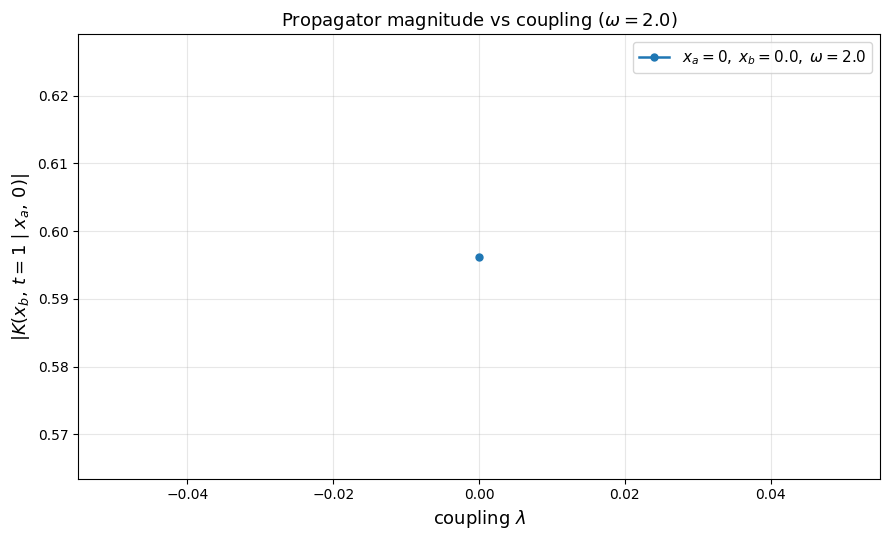

In [12]:
lam_plot = np.array(lam_list, dtype=float)

fig, ax = plt.subplots(figsize=(9, 5.5))
for xa, xb, label in endpoints:
    absK = np.array([abs(propagator(lam, xa, xb, t_ref)) for lam in lam_plot])
    ax.plot(lam_plot, absK, "o-", lw=1.8, ms=5,
            label=f"$x_a={xa},\\; x_b={xb},\\; \\omega={OMEGA}$")
ax.set_xlabel(r"coupling $\lambda$", fontsize=13)
ax.set_ylabel(r"$|K(x_b,\, t{=}1 \mid x_a,\, 0)|$", fontsize=13)
ax.set_title(rf"Propagator magnitude vs coupling ($\omega={OMEGA}$)", fontsize=13)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

### 7.2 $K$ as a function of $x_b$ for several $\lambda$, at $x_a = 0.5$ ($\omega=2$)

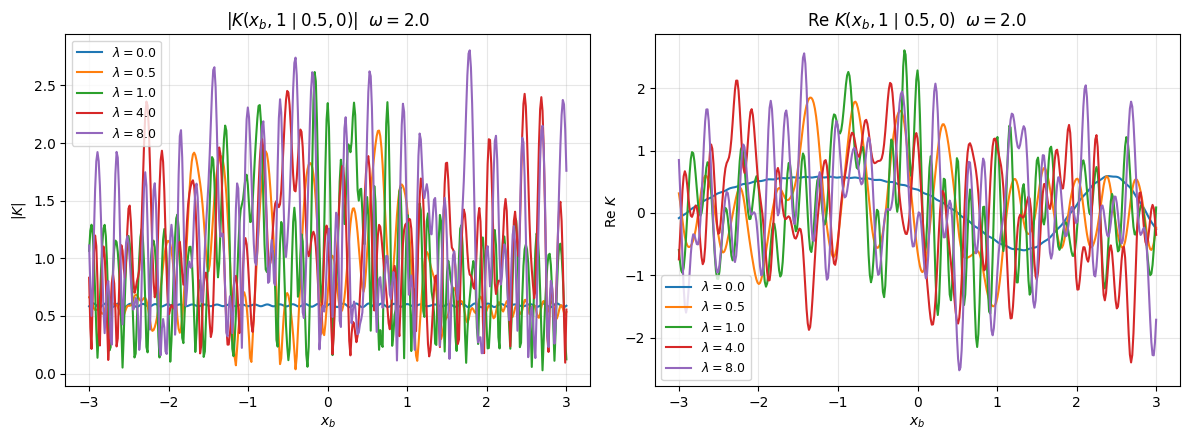

In [13]:
xb_g = np.linspace(-3, 3, 401)

for xa_fix in [0.5]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for lam in [0.0, 0.5, 1.0, 4.0, 8.0]:
        Kl = propagator(lam, xa_fix, xb_g, t_ref)[0]
        axes[0].plot(xb_g, np.abs(Kl), label=f"$\\lambda={lam}$")
        axes[1].plot(xb_g, np.real(Kl), label=f"$\\lambda={lam}$")
    for ax in axes:
        ax.set_xlabel(r"$x_b$"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    axes[0].set_ylabel(r"$|K|$")
    axes[0].set_title(fr"$|K(x_b,1 \mid {xa_fix},0)|$  $\omega={OMEGA}$")
    axes[1].set_ylabel(r"Re $K$")
    axes[1].set_title(fr"Re $K(x_b,1 \mid {xa_fix},0)$  $\omega={OMEGA}$")
    plt.tight_layout(); plt.show()

## Summary

| # | Sanity check | What it catches |
|---|-------------|----------------|
| 1 | Composition: $K(t_1{+}t_2) = \int K(t_1)K(t_2)\,dx'$ | Wrong eigenvalues or eigenfunctions |
| 2 | Diagonalise $K_E$ matrix → eigenvalues $= e^{-\beta E_n}$ | Wavefunction errors; grid artefacts |
| 3 | $\langle x^2 \rangle_\beta$ from $K_E$ diagonal vs from spectrum | Errors in $K_E$ or in the $x^2$ matrix |
| 4 | Parity: $K(-x_b \mid -x_a) = K(x_b \mid x_a)$ | Symmetry violations |
| 5 | Harmonic limit: $K \to K_\mathrm{HO}$ as $\lambda \to 0$ | Convention errors; normalisation |

**For ML benchmarking:** pick $(x_a, x_b, t, \lambda)$, get reference $K$ from this notebook, compare. If there is disagreement, the *kind* of sanity-check failure tells you what is broken.

**Validity:** $\lambda \leq 100$ with $N=400$ gives machine precision for low-lying states. For $\lambda \gg 100$, use a scaled basis.